In [1]:


from Nozzle_1D import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



In [2]:
SUPERCOARSE = Nozzle("inputs/Medium_inputs.nml")
SUPERCOARSE.CFL = .1
SUPERCOARSE.NI = 15

self = SUPERCOARSE 
self.CFL = .3
self.iter_max = 78000

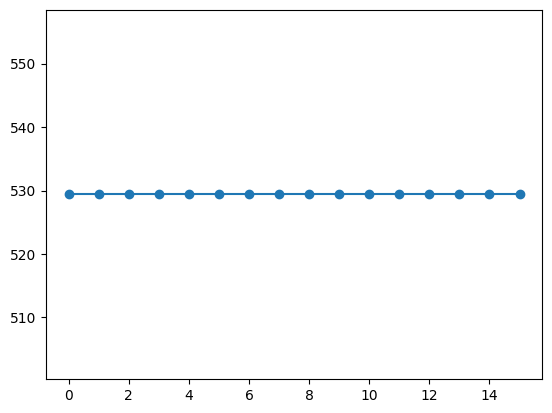

In [3]:
self.set_arrays()
self.set_geometry()
self.set_initial_conditions()
plt.plot(self.V[:,1],"-o")


[579.6497773  528.88896078 529.37921584 529.37921584 529.37921584
 529.37921584 529.37921584 529.37921584 529.37921584 529.37921584
 529.37921584 529.37921584 529.37921584 529.37921584] [528.88896078 529.37921584 529.37921584 529.37921584 529.37921584
 529.37921584 529.37921584 529.37921584 529.37921584 529.37921584
 529.37921584 529.37921584 529.37921584 529.37921584]


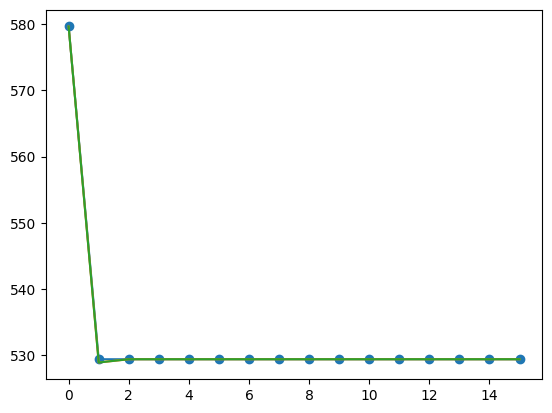

In [4]:

self.set_boundary_conditions()
plt.plot(self.V[:,1],"-o")
R1 = self.iteration_step()
self.set_boundary_conditions()
plt.plot(self.V[:,1],"-")

shift = self.FL_FR_FUNC(i_plus_half=False)
u_L,u_R = shift(self.V[:,1])  # Velocity
self.set_boundary_conditions()
plt.plot(self.V[:,1],"-")
print(u_L,u_R)

In [5]:
shift = self.FL_FR_FUNC(i_plus_half=True)
u_L,u_R = shift(self.V[:,1])  # Velocity

Iteration: 1 0.9670191809897859
Iteration: 101 0.374144189487259
Iteration: 201 0.29618052115698573
Iteration: 301 0.23310717631652103
Iteration: 401 0.1542462908539
Iteration: 501 0.11114903963230921
Iteration: 601 0.08583769590442947
Iteration: 701 0.0550410220202651
Iteration: 801 0.025569054843351414
Iteration: 901 0.008793628509395746
Iteration: 1001 0.0024302488264893118
Iteration: 1101 0.0005778648451114932
Iteration: 1201 0.00012318440156965034
Iteration: 1301 2.40967586024834e-05
Iteration: 1401 4.387912564520661e-06
Iteration: 1501 7.51255031419992e-07
Iteration: 1601 1.218622176096459e-07
Iteration: 1701 1.8844899524702403e-08
Iteration: 1801 2.792572976034426e-09
Iteration: 1901 3.98290998339571e-10
Iteration: 2001 5.4878417959237405e-11
Iteration: 2101 7.327907610266172e-12
Converged at Rk/R1: 9.503872235762246e-13 in 2200 iterations.


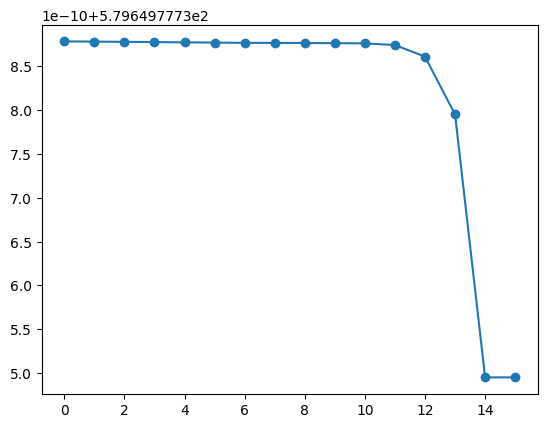

In [6]:
self.RUN_SIMULATION(verbose=True)

self.set_boundary_conditions()
plt.plot(self.V[:,1],"-o")

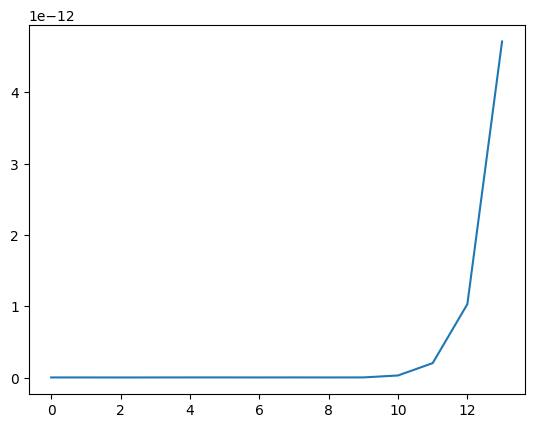

In [7]:
plt.plot(self.residual[:,0])

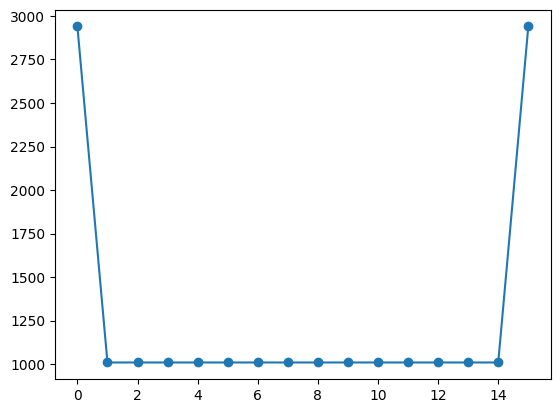

In [8]:
plt.plot(self.U[:,2],"-o")

In [9]:
F_plus_1_2 = self.f_convective(i_plus_half=True)#+self.f_pressure_flux(i_plus_half=True)
F_minus_1_2 = self.f_convective(i_plus_half=False)#+self.f_pressure_flux(i_plus_half=False)
F_minus_1_2

array([[2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05],
       [2.87392099e+00, 1.66586766e+03, 6.26417854e+05]])

In [10]:
F_plus_1_2 = self.compute_roe_flux(i_plus_half=True)
F_minus_1_2 = self.compute_roe_flux(i_plus_half=False)

F_minus_1_2

array([[7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06],
       [7.95051226e+00, 4.54287055e+03, 1.73294355e+06]])

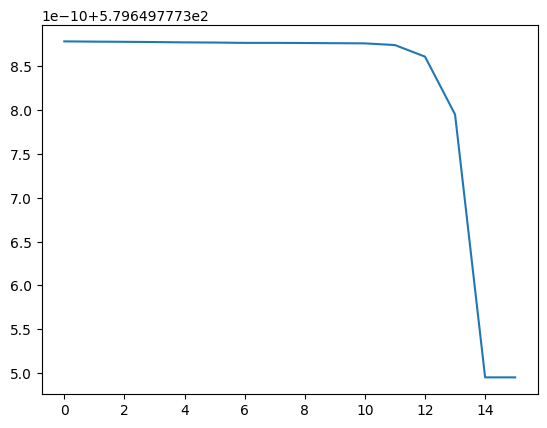

In [11]:
plt.plot(self.V[:,1])

In [12]:
self.V[:,1]

array([579.6497773, 579.6497773, 579.6497773, 579.6497773, 579.6497773,
       579.6497773, 579.6497773, 579.6497773, 579.6497773, 579.6497773,
       579.6497773, 579.6497773, 579.6497773, 579.6497773, 579.6497773,
       579.6497773])